# Abstract

El siguiente análisis se realiza sobre un dataset real asociado a ventas asociadas a uno de los principales retailers argentinos. El mismo recopila datos asociados no sólo a las transacciones realizadas por clientes en diferentes momentos, sino también datos de formas de pago utilizadas y comportamiento de compra (online, sucursal) que permitirán analizar comportamientos de compra reales.

El objetivo será analizar la composición del set de datos, el potencial grado de correlación entre distintas variables que permita inferir potenciales comportamientos de compra, ya sea identificando futuras categorías de compra, próximos períodos de compra, así como también estacionalidad en la venta.

Para este objetivo se iniciará con el análisis exploratorio del dataset identificando valores nulos, outliers y potenciales anomalías. Luego mediante la comparación visual con gráficos se analizará tanto la correlación entre variables como la distribución de las mismas. 

Con esta información se pretende obtener un marco de datos limpio, optimizado y preparado para la interpretación a través de un modelo que permita realizar futuras predicciones de comportamiento de compra para aquellos clientes recurrentes que tengan intención de volver a comprar en alguna de las 10 tiendas analizadas.

## Análisis Exploratorio

### Análisis Estructural

Procedemos a analizar la estructura del dataset y composición incial. 

In [1]:
#ordeno todos los imports utilizados en el proyecto
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/aurocca/coderhouse-2026-DSII/refs/heads/main/coder_ventas_procesado.csv")

In [3]:
df.shape

(96927, 27)

El DS contiene 96.927 transacciones de compra y 27 columnas de atributos a analizar.

Inicialmente con esta cantidad de datos nos sentimos cómodos para analizar comportamiento en el período que den los datos (horas, días, semanas, meses , etc.) y al tener 27 columnas, veremos con cuantas nos quedamos al final del análisis pero parecerían ser suficientes para obtener inferencias interesantes de comportamiento.

In [4]:
df.head()

,VEN_FECHA_VENTA,VEN_ID_DOCUMENTO,VEN_ID_ORDEN,VEN_CANAL,VEN_SUBCANAL,VEN_ID_SUCURSAL,VEN_LEGAJO_VENDEDOR,VEN_ID_ARTICULO,VEN_DS_ARTICULO,VEN_MARCA,...,VEN_UNIDADES_GAREX,VEN_FG_MARKETPLACE,VEN_SELLER,VEN_DELIVERY,VEN_FG_ENVIO_DOMICILIO,VEN_FORMA_PAGO,VEN_TARJETA,VEN_BANCO_TARJETA,VEN_NRO_ORDEN,VEN_ID_CLIENTE
0,May 23 2022 12:00AM,340,NaN,FISICAS,FISICAS,124,209,363910,MULTIF.EPSON ECOTANK - L3210,EPSON,...,1,0,DESCONOCIDO,NaN,0,CREDITO,NaN,UNK,2,6931639
1,May 23 2022 12:00AM,340,NaN,FISICAS,FISICAS,147,439,90193,TER.SENORIAL TT 65LT EL ZA,SENORIAL,...,1,0,DESCONOCIDO,NaN,0,CREDITO,NaN,UNK,3,6444136
2,May 23 2022 12:00AM,340,NaN,FISICAS,FISICAS,8,828,781497,SAMSUNG GALAXY M12 NEGRO,SAMSUNG,...,0,0,DESCONOCIDO,NaN,0,CREDITO,NaN,UNK,1,18841002
3,May 23 2022 12:00AM,340,NaN,FISICAS,FISICAS,84,1585,781665,MOTOROLA EDGE 20 PROBLANCO+C/REMO,MOTOROLA,...,1,0,DESCONOCIDO,NaN,0,CREDITO,NARANJA,UNK,2,18094697
4,May 23 2022 12:00AM,340,NaN,FISICAS,FISICAS,8,508,502263,"""TV.LED 39""""RCA XF39CHF""",RCA,...,1,0,DESCONOCIDO,NaN,0,CREDITO,VISA ELECTRON,UNK,3,5339440


Inicialmente se ve que la distribución de columnas es la siguiente:

**VEN_FECHA_VENTA:** Fecha en la cual se realizó la transacción en formato M D Y hh:mm AM/PM. Seguramente sea mejor acomodar este formato a un YYYY-MM-DD HH:MM (hay que analizar si la hora siempre es 12:00AM sacarla del análisis ya que no da información).

**VEN_ID_DOCUMENTO:** Tipo de Documento, hay que analizar la cantidad de elementos distintos ya que si son siempre el mismo, no vale a la pena tenerlo.

**VEN_ID_ORDEN:** Identificador de la orden de venta que es la que contiene luego internamente datos de la compra asociada a la cantidad de artículos comprados. Vemos que tiene no numéricos, con lo cual los asumiremos como nulos y luego analizaremos si tiene sentido una transacción sin orden.

**VEN_CANAL:** Al momento no tenemos mucha información a simple vista pero asumimos que es el canal usado, que puede ser Físico (compra en sucural) o bien Online o similar para compras de Ecommerce.

**VEN_SUB_CANAL:** En este caso asumimos que es una subdivisión del canal, deberíamos analizar los tipos de compras existentes y analizar que distribución tienen por subcanal.

**VEN_ID_SUCURSAL:** Identificador de la sucursal en la cual se realizó la compra. Hay que analizar en los casos de venta de ecommerce que valor le asigna.

**VEN_LEGAJO_VENDEDOR:** Identificador del vendedor que colaboró en la compra. Hay que ver que valor le asigna en compras online, ya que seguramente en esos casos esta columna no tenga sentido.

**VEN_ID_ARTICULO:** Identificador del Artículo comprado, en general asociado al término SKU. 

**VEN_DS_ARTICULO:** Detalle descriptivo del artículo comprado.

**VEN_MARCA:** Marca del artículo comprado.

**VEN_ID_RUBRO:** ID de la Categoría del artúculo comprado.

**VEN_DS_RUBRO:** Detalle Categoría del artúculo comprado.

**VEN_ID_SUBRUBRO:** Id de la Subcategoría del artículo comprado.

**VEN_DS_SUBRUBRO:** Detalle de la Subcategoría del artículo comprado.

**VEN_PRECIO_VTA** Importe total de la transacción.

**VEN_UNIDADES:** Cantidad de unidades compradas en la transacción.

**VEN_UNIDADES_GAREX:** En base a lo que infiero según el nombre de la columna, que son las unidades que se compraron con garantía extendida o similar.

**VEN_FG_MARKETPLACE:** Hay que analizar los valores de esta columna es pero entiendo que refiere a si la compra se realizó por Marketplace o bien por productos de venta interna, es decir.

**VEN_SELLER:** Identificador del Vendedor del artículo.

**VEN_DELIVERY:** Entiendo que es una columna que indica si el artículo tuvo delivery o no.

**VEN_FG_ENVIO_DOMICILIO:** Hay que analizar la diferncia con la columna anterior, pero refiere al envío al domicilio del artículo comprado. 

**VEN_FORMA_PAGO:** Forma de Pago utilizado en la compra.

**VEN_TARJETA:** Tarjeta utilizada en la compra.

**VEN_BANCO_TARJETA:** Banco de la Tarjeta utilizada en la compra.

**VEN_NRO_ORDEN:** Identificador de la orden de compra, hay que analizar que diferencia tiene este de la columna VEN_ID_ORDEN, pero puede ser que este sea el identificador numérico de la orden y el otro sea un alfanumérico, por eso también dice NaN en algunas columnas. Si fuese así, nos quedaremos con esta columna para analizar en vez de la anterior.

**VEN_ID_CLIENTE:** Identificador del cliente que realizó la compra.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96927 entries, 0 to 96926
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   VEN_FECHA_VENTA         96927 non-null  object
 1   VEN_ID_DOCUMENTO        96927 non-null  int64 
 2   VEN_ID_ORDEN            38192 non-null  object
 3   VEN_CANAL               96927 non-null  object
 4   VEN_SUBCANAL            96927 non-null  object
 5   VEN_ID_SUCURSAL         96927 non-null  int64 
 6   VEN_LEGAJO_VENDEDOR     96927 non-null  int64 
 7   VEN_ID_ARTICULO         96927 non-null  int64 
 8   VEN_DS_ARTICULO         96927 non-null  object
 9   VEN_MARCA               96927 non-null  object
 10  VEN_ID_RUBRO            96927 non-null  object
 11  VEN_DS_RUBRO            96927 non-null  object
 12  VEN_ID_SUBRUBRO         96927 non-null  int64 
 13  VEN_DS_SUBRUBRO         96927 non-null  object
 14  VEN_PRECIO_VTA          96927 non-null  object
 15  VE

Viendo el total de datos que tiene cada columna vemos que las columnas **VEN_ID_ORDEN**,**VEN_DELIVERY** y **VEN_TARJETA** tienen valores nulos en alguno de sus registros.

Ahora como el VEN_NRO_ORDEN tiene todos los datos y es numérico, entonces es posible quedarme con este último en vez de usar el VEN_ID_ORDEN.

In [6]:
#Veo como son los valores y cuantos valores distintos hay en la columna VEN_ID_ORDEN
valores_distintos = df['VEN_ID_ORDEN'].value_counts()
print(valores_distintos)

VEN_ID_ORDEN
v31108648frvg-01    3
v45796021frvg-01    2
v32874349frvg-01    2
v37840519frvg-01    2
v46733786frvg-01    2
                   ..
v84087094frvg-01    1
v84169721frvg-01    1
16376532            1
v84153849frvg-01    1
6509470             1
Name: count, Length: 38111, dtype: int64


Tomo el ejemplo para el VEN_ID_ORDEN "v31108648frvg-01" y analizo ese valor vs el VEN_NRO_ORDEN para ver si se mantiene la relación, por ejemplo que los registros que me muestren me den el mismo VEN_NRO_ORDEN (no importa el valor) para los que tengan el mismo VEN_ID_ORDEN.valores_distintos

In [7]:
df_filtrado = df[df['VEN_ID_ORDEN'] == 'v31108648frvg-01'][['VEN_ID_ORDEN', 'VEN_NRO_ORDEN']]
print(df_filtrado)

           VEN_ID_ORDEN  VEN_NRO_ORDEN
56018  v31108648frvg-01             40
56019  v31108648frvg-01             30
56020  v31108648frvg-01             10


A simple vista veo que son IDs distintos para el mismo ID_ORDEN así que sumo algunos valores más como ser el artículo, la fecha y el cliente para entender mejor la venta de ese caso.

In [8]:
df_filtrado = df[df['VEN_ID_ORDEN'] == 'v31108648frvg-01'][['VEN_FECHA_VENTA','VEN_UNIDADES','VEN_ID_ARTICULO','VEN_ID_CLIENTE','VEN_ID_ORDEN', 'VEN_NRO_ORDEN']]
print(df_filtrado)

           VEN_FECHA_VENTA VEN_UNIDADES  VEN_ID_ARTICULO  VEN_ID_CLIENTE  \
56018  Mar  4 2021 12:00AM            2           595217        47362781   
56019  Mar  4 2021 12:00AM            1           595231        47362781   
56020  Mar  4 2021 12:00AM            1           595247        47362781   

           VEN_ID_ORDEN  VEN_NRO_ORDEN  
56018  v31108648frvg-01             40  
56019  v31108648frvg-01             30  
56020  v31108648frvg-01             10  


Ok, ahora queda más claro en la misma orden de compra, el cliente 47362781 compró 2 productos de 595217, 1 de 595231 y otro de 595247. Pero en el NRO_ORDEN tiene 3 valores distintos entonces, no podemos tomar ese valor como referencia numérica de la orden.

Ahora lo que sí veo es que existe un patrón para el número de la orden en base al ID, así que veo si todos los valores de la columna VEN_ID_ORDEN presentan el mismo formato para poder extraer el número de la orden y usar ese.

In [9]:
# Definir dos patrones mediante expresiones regulares
patron_formato = r'^v\d+frvg.*$'  # v + números + frvg-01
patron_numerico = r'^\d+$'  # solo números

# Crear columnas booleanas
df['cumple_formato'] = df['VEN_ID_ORDEN'].astype(str).apply(
    lambda x: bool(re.match(patron_formato, x)) if pd.notna(x) else False
)

df['es_numerico'] = df['VEN_ID_ORDEN'].astype(str).apply(
    lambda x: bool(re.match(patron_numerico, x)) if pd.notna(x) else False
)

# Combinar ambas condiciones
df['cumple_alguno'] = df['cumple_formato'] | df['es_numerico']

# Contar resultados
cumple_alguno = df['cumple_alguno'].sum()
total = len(df)
print(f"Registros que cumplen ALGUNO de los dos patrones: {cumple_alguno} de {total}")
print(f"Porcentaje: {(cumple_alguno/total)*100:.2f}%")

# Ver ejemplos que NO cumplen ninguno
no_cumple_ninguno = df[~df['cumple_alguno']]['VEN_ID_ORDEN'].unique()
print(f"\nValores que NO cumplen NINGUNO de los patrones:")
print(no_cumple_ninguno[:10])

Registros que cumplen ALGUNO de los dos patrones: 36610 de 96927
Porcentaje: 37.77%

Valores que NO cumplen NINGUNO de los patrones:
[nan 'CBC-JVJHOVSNO-657003269' 'CBC-IUVXHRBQZ-657217734'
 'CBC-UDXJHXXKY-535422020' 'CBC-YCLAXQRHL-644180119' 'mrc-2103975365'
 'mrc-2123715167' 'CBC-GISWKBOOG-56912432' 'mrc-2102855653'
 'CBC-TDUQFOLSA-57803024']


Ok, entonces visto esto sólo el 37,17% de los registros cumplen la lógica de v-NUMERO-frgXXX o que es un número. Entonces descarto la posiblidad de encodearlo como número. Extrayendo info de la orden. Lo que seguramente pueda hacer es transformar esa orden en un valor númerico pero no con info directa del campo.

Procedo ahora a convertir las columnas object en formatos conocidos que me permitan analizar mejor la información.

Por un lado el campo fecha de la venta, luego los númericos que sean IDs y por otro el float para el precio de venta.

In [10]:
#Convierto la Fecha de Venta en un date para luego analizarlo mejor.
df['VEN_FECHA_VENTA'] = pd.to_datetime(df['VEN_FECHA_VENTA'], format="%b %d %Y %I:%M%p").dt.date
print(type(df['VEN_FECHA_VENTA'][0]))

<class 'datetime.date'>


In [11]:
#Convierto el Precio de Venta en float, previamente como algunos elementos tenían comillas simples entonces se las sacamos previamente para luego pasarlo a float.
df['VEN_PRECIO_VTA'] = df['VEN_PRECIO_VTA'].astype(str).str.strip("'").astype(float)
print(type(df['VEN_PRECIO_VTA'][0]))
print(df['VEN_PRECIO_VTA'].head())

<class 'numpy.float64'>
0     49599.0
1     31999.0
2     45999.0
3    126699.0
4     48999.0
Name: VEN_PRECIO_VTA, dtype: float64


In [12]:
#Convierto las columnas numéricas a int64, limpiando comillas si existen
columnas_a_int64 = ['VEN_ID_DOCUMENTO', 'VEN_ID_SUCURSAL', 'VEN_ID_ARTICULO', 'VEN_ID_RUBRO', 'VEN_ID_SUBRUBRO', 'VEN_UNIDADES', 'VEN_UNIDADES_GAREX']

for col in columnas_a_int64:
    df[col] = df[col].astype(str).str.strip("'").astype('int64')
    print(f"{col}: {df[col].dtype}")

VEN_ID_DOCUMENTO: int64
VEN_ID_SUCURSAL: int64
VEN_ID_ARTICULO: int64
VEN_ID_RUBRO: int64
VEN_ID_SUBRUBRO: int64
VEN_UNIDADES: int64
VEN_UNIDADES_GAREX: int64


### Análisis de Valores Nulos y Outliers

Procedemos a analizar la presencia de valores nulos en el dataset y detectar posibles outliers que puedan afectar nuestros análisis posteriores.

In [13]:
# Valores nulos por columna
null_counts = df.isnull().sum()
null_percentages = (null_counts / len(df)) * 100

print("Valores nulos por columna:")
for col in df.columns:
    if null_counts[col] > 0:
        print(f"{col}: {null_counts[col]} nulos ({null_percentages[col]:.2f}%)")

if null_counts.sum() == 0:
    print("No hay valores nulos en el dataset.")
else:
    print(f"\nTotal de valores nulos: {null_counts.sum()}")

Valores nulos por columna:
VEN_ID_ORDEN: 58735 nulos (60.60%)
VEN_SELLER: 48 nulos (0.05%)
VEN_DELIVERY: 59408 nulos (61.29%)
VEN_TARJETA: 23541 nulos (24.29%)

Total de valores nulos: 141732


### Análisis de Outliers para VEN_FECHA_VENTA

La idea de este análisis es ver la distribución de las fecha de Venta a lo largo del tiempo para ver si existe un grupo muy relevante de transacciones realizadas en un período determinado y verificar si es posible acortar el análisis a un período más estable de fechas.

### Tratamiento de Valores Nulos en VEN_ID_ORDEN

Como identificamos que el 60.6% de los registros no tienen VEN_ID_ORDEN, pero todas las transacciones deberían tener un identificador único, vamos a completar estos valores nulos con un identificador generado que no interfiera con los existentes.

La estrategia será concatenar el VEN_ID_CLIENTE con un timestamp único derivado de VEN_FECHA_VENTA, asegurando que cada registro tenga un ID único.

In [14]:
ordenes_existentes = df['VEN_ID_ORDEN'].dropna().unique()
print(f"Cantidad de VEN_ID_ORDEN únicos existentes: {len(ordenes_existentes)}")
print("Ejemplos de VEN_ID_ORDEN existentes:")
for i, orden in enumerate(ordenes_existentes[:5]):
    print(f"  {i+1}. {orden}")

# Verificar si contienen algún patrón común
tiene_v = sum(1 for orden in ordenes_existentes if str(orden).startswith('v'))
tiene_frvg = sum(1 for orden in ordenes_existentes if 'frvg' in str(orden))

print(f"\nEstadísticas del formato existente:")
print(f"  Inician con 'v': {tiene_v} ({tiene_v/len(ordenes_existentes)*100:.1f}%)")
print(f"  Contienen 'frvg': {tiene_frvg} ({tiene_frvg/len(ordenes_existentes)*100:.1f}%)")

# Contar nulos antes
nulos_antes = df['VEN_ID_ORDEN'].isnull().sum()
print(f"Valores nulos antes: {nulos_antes}")

# Crear identificadores únicos para los nulos
# Usaremos el formato: "GEN-{VEN_ID_CLIENTE}-{INDICE}"
# El índice asegura unicidad absoluta

mask_nulos = df['VEN_ID_ORDEN'].isnull()

if mask_nulos.sum() > 0:
    # Crear IDs únicos usando el índice del dataframe
    df.loc[mask_nulos, 'VEN_ID_ORDEN'] = df.loc[mask_nulos].apply(
        lambda row: f"GEN-{row['VEN_ID_CLIENTE']}-{int(row.name)}",
        axis=1
    )

# Verificar que no hay colisiones con existentes
ordenes_existentes_set = set(df.loc[~mask_nulos, 'VEN_ID_ORDEN'].dropna())
ordenes_generadas = set(df.loc[mask_nulos, 'VEN_ID_ORDEN'])
colisiones = ordenes_existentes_set.intersection(ordenes_generadas)

print(f"Valores nulos después: {df['VEN_ID_ORDEN'].isnull().sum()}")
print(f"IDs generados: {len(ordenes_generadas)}")
print(f"Colisiones con IDs existentes: {len(colisiones)}")

if len(colisiones) > 0:
    print("¡ERROR! Hay colisiones con IDs existentes:")
    for colision in list(colisiones)[:5]:
        print(f"  {colision}")
else:
    print("✅ Éxito: No hay colisiones con IDs existentes.")

Cantidad de VEN_ID_ORDEN únicos existentes: 38111
Ejemplos de VEN_ID_ORDEN existentes:
  1. v40264210frvg-01
  2. v40252321frvg-01
  3. v40261193frvg-01
  4. v40263594frvg-01
  5. v40257396frvg-01

Estadísticas del formato existente:
  Inician con 'v': 23334 (61.2%)
  Contienen 'frvg': 23334 (61.2%)
Valores nulos antes: 58735
Valores nulos después: 0
IDs generados: 58735
Colisiones con IDs existentes: 0
✅ Éxito: No hay colisiones con IDs existentes.


In [15]:
#Verificación final del tratamiento de VEN_ID_ORDEN
total_registros = len(df)
unicos_orden = df['VEN_ID_ORDEN'].nunique()
nulos_despues = df['VEN_ID_ORDEN'].isnull().sum()

print(f"Total de registros: {total_registros}")
print(f"VEN_ID_ORDEN únicos: {unicos_orden}")
print(f"Valores nulos restantes: {nulos_despues}")
print(f"Cobertura: {(1 - nulos_despues/total_registros)*100:.2f}%")

# Verificar distribución de tipos de ID
df['tipo_id_orden'] = df['VEN_ID_ORDEN'].apply(
    lambda x: 'ORIGINAL' if pd.notnull(x) and not str(x).startswith('GEN-') else 'GENERADO'
)

distribucion = df['tipo_id_orden'].value_counts()
print(f"\nDistribución de tipos de ID:")
print(f"  Originales: {distribucion.get('ORIGINAL', 0)} ({distribucion.get('ORIGINAL', 0)/total_registros*100:.2f}%)")
print(f"  Generados: {distribucion.get('GENERADO', 0)} ({distribucion.get('GENERADO', 0)/total_registros*100:.2f}%)")

# Limpiar columna temporal
df.drop('tipo_id_orden', axis=1, inplace=True)

Total de registros: 96927
VEN_ID_ORDEN únicos: 96846
Valores nulos restantes: 0
Cobertura: 100.00%

Distribución de tipos de ID:
  Originales: 38192 (39.40%)
  Generados: 58735 (60.60%)


### Análisis de Outliers para campos numéricos relevantes

Nos enfocamos en los valores para VEN_PRECIO_VTA, VEN_UNIDADES y VEN_UNIDADES_GAREX para analizar las cantidades de artículos y los precio de venta, junto a sus posibles valores outliers ya que son los más relevantes en caso que queramos aplicar regresiones lineales o calculos sobre valores de transacción específicos.


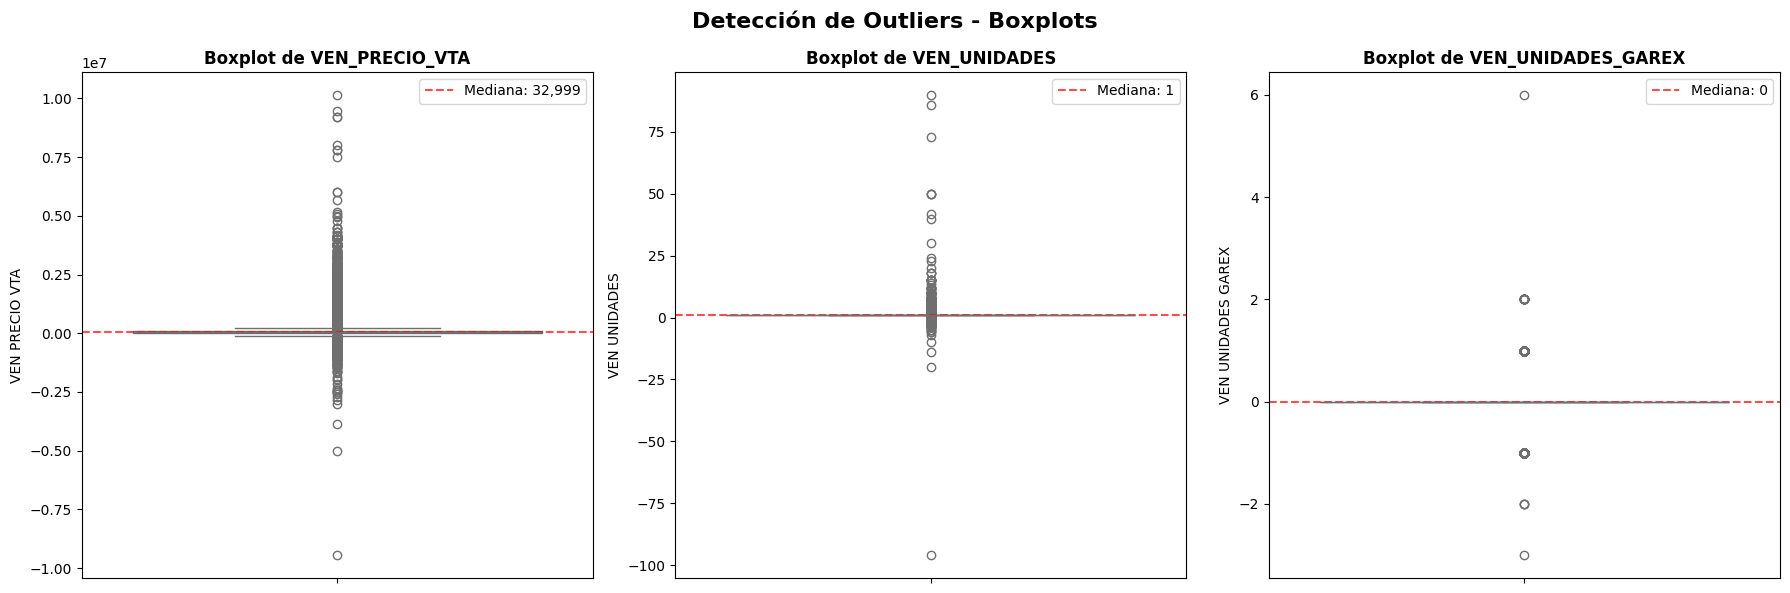

In [16]:
# Configurar el estilo de los gráficos boxplot
plt.style.use('default')
sns.set_palette("husl")

# Crear figura con subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Detección de Outliers - Boxplots', fontsize=16, fontweight='bold')

numeric_columns = ['VEN_PRECIO_VTA', 'VEN_UNIDADES', 'VEN_UNIDADES_GAREX']

for i, col in enumerate(numeric_columns):
    if col in df.columns:
        # Crear boxplot
        sns.boxplot(y=df[col], ax=axes[i], color='skyblue')

        # Configurar título y labels
        axes[i].set_title(f'Boxplot de {col}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel(col.replace('_', ' '), fontsize=10)

        # Agregar estadísticas en el gráfico
        median = df[col].median()
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        axes[i].axhline(median, color='red', linestyle='--', alpha=0.7, label=f'Mediana: {median:,.0f}')
        axes[i].legend()

plt.tight_layout()
plt.show()

En este caso lo que más interesa a nivel de precio de venta, unidades y unidades garex serían los valores negativos, porque luego el resto de los valores se ven lógicos para transacciones de compra, siendo que la mediana de compra suele ser 1 unidad, sin garantía extendida y un ticket promedio en ARS de $32.999 (un ticket promedio normal para compras de retail, que indicaría que no suele predominar la compra de artículos caros sino de valor medio/bajo).

In [17]:
#Análisis de outliers usando el método IQR
numeric_columns = ['VEN_PRECIO_VTA', 'VEN_UNIDADES', 'VEN_UNIDADES_GAREX']

for col in numeric_columns:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers)

        print(f"\n{col}:")
        print(f"  Q1 (25%): {Q1:,.2f}")
        print(f"  Q3 (75%): {Q3:,.2f}")
        print(f"  IQR: {IQR:,.2f}")
        print(f"  Límite inferior: {lower_bound:,.2f}")
        print(f"  Límite superior: {upper_bound:,.2f}")
        print(f"  Outliers detectados: {outlier_count} ({(outlier_count/len(df))*100:.2f}%)")

        if outlier_count > 0:
            print(f"  Valores outliers - Min: {outliers[col].min():,.2f}, Max: {outliers[col].max():,.2f}")

print("\n" + "="*50)


VEN_PRECIO_VTA:
  Q1 (25%): 7,993.50
  Q3 (75%): 98,999.00
  IQR: 91,005.50
  Límite inferior: -128,514.75
  Límite superior: 235,507.25
  Outliers detectados: 14100 (14.55%)
  Valores outliers - Min: -9,449,999.00, Max: 10,152,041.00

VEN_UNIDADES:
  Q1 (25%): 1.00
  Q3 (75%): 1.00
  IQR: 0.00
  Límite inferior: 1.00
  Límite superior: 1.00
  Outliers detectados: 5699 (5.88%)
  Valores outliers - Min: -96.00, Max: 90.00

VEN_UNIDADES_GAREX:
  Q1 (25%): 0.00
  Q3 (75%): 0.00
  IQR: 0.00
  Límite inferior: 0.00
  Límite superior: 0.00
  Outliers detectados: 10585 (10.92%)
  Valores outliers - Min: -3.00, Max: 6.00



Analizando lo mismo que antes pero con IQR vemos que existen en todas las variables valores negativos que tendremos que eliminar, ya que no tiene sentido en transacciones de compra tenerlas en cuenta (seguramente se refieren a reintegros o datos erroneos).

Pero además que los valores muy grandes para el precio de venta como ser más de ARS 10M no son ilógicos ya que sumando varias unidades de artículos de ticket alto, como ser heladeras, aires acondicionados, notebooks, etc. el valor puede llegar a tener sentido. Con lo cual sólo vamos a enfocarnos en eliminar posteriormente los valores negativos de estas 3 variables.

=== OUTLIERS EN FECHA DE VENTA ===
Primera fecha: 2019-01-02 00:00:00
Última fecha : 2026-02-03 00:00:00
Q1         : 2021-05-23 00:00:00
Q3         : 2024-10-16 00:00:00
IQR        : 1242 days 00:00:00
Total no-null: 96927
Fuera de rango 2019-01-01 - 2027-12-31: 0 (0.00%)
Fechas menores a 2019-01-01 (5 primeros):
Empty DataFrame
Columns: [VEN_FECHA_VENTA, VEN_ID_CLIENTE]
Index: []
Fechas mayores a 2027-12-31 (5 primeros):
Empty DataFrame
Columns: [VEN_FECHA_VENTA, VEN_ID_CLIENTE]
Index: []


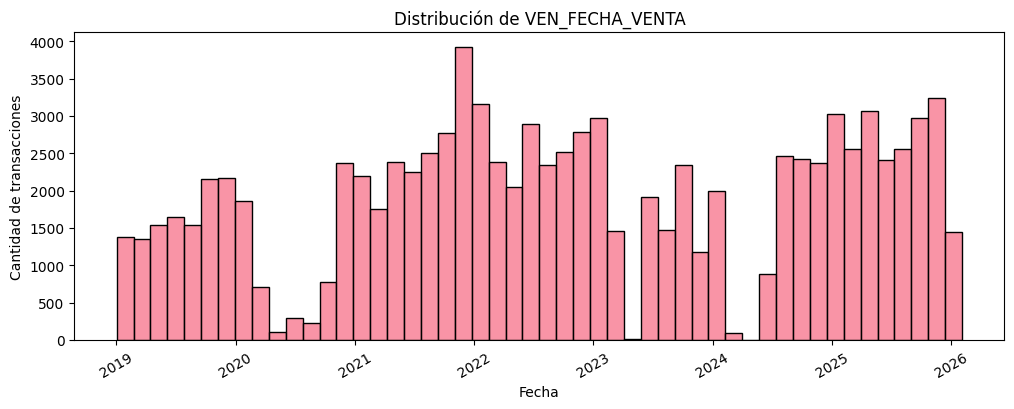

In [18]:
# Outliers/ruido en fecha de venta
print("=== OUTLIERS EN FECHA DE VENTA ===")

df['VEN_FECHA_VENTA'] = pd.to_datetime(df['VEN_FECHA_VENTA'], errors='coerce')
min_fecha = df['VEN_FECHA_VENTA'].min()
max_fecha = df['VEN_FECHA_VENTA'].max()
q1_fecha = df['VEN_FECHA_VENTA'].quantile(0.25)
q3_fecha = df['VEN_FECHA_VENTA'].quantile(0.75)

print(f"Primera fecha: {min_fecha}")
print(f"Última fecha : {max_fecha}")
print(f"Q1         : {q1_fecha}")
print(f"Q3         : {q3_fecha}")
print(f"IQR        : {q3_fecha - q1_fecha}")
print(f"Total no-null: {df['VEN_FECHA_VENTA'].notna().sum()}")

# Perímetro esperado
lim_inf = pd.Timestamp("2019-01-01")
lim_sup = pd.Timestamp("2027-12-31")

fuera_rango = df[(df['VEN_FECHA_VENTA'] < lim_inf) | (df['VEN_FECHA_VENTA'] > lim_sup)]
print(f"Fuera de rango {lim_inf.date()} - {lim_sup.date()}: {len(fuera_rango)} ({len(fuera_rango)/len(df)*100:.2f}%)")

# Mostrar ejemplo de fechas anómalas
print(f"Fechas menores a {lim_inf.date()} (5 primeros):")
print(fuera_rango.nsmallest(5, 'VEN_FECHA_VENTA')[['VEN_FECHA_VENTA', 'VEN_ID_CLIENTE']])

print(f"Fechas mayores a {lim_sup.date()} (5 primeros):")
print(fuera_rango.nlargest(5, 'VEN_FECHA_VENTA')[['VEN_FECHA_VENTA', 'VEN_ID_CLIENTE']])

# Visual: histograma de fechas
plt.figure(figsize=(12,4))
sns.histplot(df['VEN_FECHA_VENTA'].dropna(), bins=50, kde=False)
plt.title("Distribución de VEN_FECHA_VENTA")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de transacciones")
plt.xticks(rotation=30)
plt.show()

Como se puede ver la distribución de ventas se da con picos entre diferentes fechas pero ningún patron hace creer que es necesario eliminar datos por inconsistencias, al contrario sie bien existen períodos con pocas ventas, mantendremos las mismas.

Ahora analizamos los valores negativos asociados al precio de venta y los eliminamos ya que nos interesan las ventas y no los reintegros generados por transacciones en la base.

In [19]:
# Filtrar transacciones con VEN_PRECIO_VTA (reintegros) o VEN_ID_CLIENTE cero/negativo (errores) 
antes = len(df)
negativos_price = df[df['VEN_PRECIO_VTA'] < 0]
print(f"Transacciones con precio negativo: {len(negativos_price)} ({len(negativos_price)/antes*100:.2f}%)")

negativos_clientes = df[df['VEN_ID_CLIENTE'] <= 0]
print(f"Transacciones con clientes CERO o negativos: {len(negativos_clientes)} ({len(negativos_clientes)/antes*100:.2f}%)")

negativos_garex = df[df['VEN_UNIDADES_GAREX'] < 0]
print(f"Transacciones con unidades con garantía negativas: {len(negativos_garex)} ({len(negativos_garex)/antes*100:.2f}%)")

# Eliminar registros con precio negativo
df = df[df['VEN_PRECIO_VTA'] >= 0].reset_index(drop=True)

# Eliminar registros con clientes CERO o negativos
df = df[df['VEN_ID_CLIENTE'] > 0].reset_index(drop=True)

# Reemplazo los valores negativos de VEN_UNIDADES_GAREX por cero, asumiendo que no pueden ser negativos pero podrían ser errores de carga
df.loc[df['VEN_UNIDADES_GAREX'] < 0, 'VEN_UNIDADES_GAREX'] = 0
negativos_despues = (df['VEN_UNIDADES_GAREX'] < 0).sum()
print(f"Transacciones con unidades con garantía negativas, después: {negativos_despues}")

Transacciones con precio negativo: 2922 (3.01%)
Transacciones con clientes CERO o negativos: 1246 (1.29%)
Transacciones con unidades con garantía negativas: 423 (0.44%)
Transacciones con unidades con garantía negativas, después: 0


### Normalización del Previo de Venta en USD

En un contexto inflacionario como el argentino, es necesario normalizar los valores a USD para el análisis de valor de artículos ya que sino las comparaciones no son acertadas.

Para hacer esto uso la API del BCRA para calcular para los meses que tenemos transacciones el valor del USD en ese momento y aplicarlo a cada transacción para tener una nueva columna que sea VEN_PRECIO_VTA_USD que nos permita luego analizar variaciones y tendencias de manera correcta.

In [20]:
# Crear columna VEN_PRECIO_VTA_USD - Conversión ARS a USD usando API BCRA
# Configurar API BCRA
API_URL = "https://api.bcra.gob.ar/estadisticascambiarias/v1.0/Cotizaciones/USD"
tasa_cache = {}  # Caché de tasas mensuales

def obtener_tasa_mes(year, month):
    """Obtiene tasa ARS/USD promedio para un mes específico usando API BCRA"""
    key = f"{year}-{month:02d}"
    
    if key in tasa_cache:
        return tasa_cache[key]
    
    try:
        # Calcular primer y último día del mes
        from datetime import datetime
        primer_dia = datetime(year, month, 1)
        if month == 12:
            ultimo_dia = datetime(year + 1, 1, 1)
        else:
            ultimo_dia = datetime(year, month + 1, 1)
        
        response = requests.get(
            API_URL,
            params={
                'fechaDesde': primer_dia.strftime('%Y-%m-%d'),
                'fechaHasta': ultimo_dia.strftime('%Y-%m-%d'),
                'limit': 31  # Máximo días en un mes
            },
            timeout=10
        )
        
        if response.status_code == 200:
            datos = response.json()
            if datos.get('status') == 200 and datos.get('results'):
                # Extraer todas las tasas del mes
                tasas_mes = []
                for fecha_data in datos['results']:
                    for detalle in fecha_data.get('detalle', []):
                        if detalle.get('codigoMoneda') == 'USD':
                            tasa = detalle.get('tipoCotizacion')
                            if tasa:
                                tasas_mes.append(tasa)
                
                if tasas_mes:
                    # Calcular promedio mensual
                    tasa_promedio = sum(tasas_mes) / len(tasas_mes)
                    tasa_cache[key] = tasa_promedio
                    return tasa_promedio
    except:
        pass
    
    return None

# Obtener meses únicos
meses_unicos = sorted(set((d.year, d.month) for d in df['VEN_FECHA_VENTA']))
print(f"📥 Descargando tasas para {len(meses_unicos)} meses...\n")

# Descargar tasas
for i, (year, month) in enumerate(meses_unicos, 1):
    obtener_tasa_mes(year, month)
    if i % 12 == 0:
        tasas_ok = sum(1 for k in tasa_cache.values() if k is not None)
        print(f"   {i}/{len(meses_unicos)} meses ({tasas_ok} tasas OK)")

# Función de aplicación con fallback
def convertir_a_usd(row):
    """Convierte precio a USD usando tasa mensual o promedio"""
    year, month = row['VEN_FECHA_VENTA'].year, row['VEN_FECHA_VENTA'].month
    key = f"{year}-{month:02d}"
    
    tasa = tasa_cache.get(key)
    
    if tasa is None:
        # Usar promedio si no hay tasa específica
        tasas_validas = [t for t in tasa_cache.values() if t is not None]
        tasa = sum(tasas_validas) / len(tasas_validas) if tasas_validas else 0.003
    
    return row['VEN_PRECIO_VTA'] * tasa

# Aplicar conversión
print("\n💱 Aplicando conversión ARS → USD...")
df['VEN_PRECIO_VTA_USD'] = df.apply(convertir_a_usd, axis=1)

# Estadísticas
print(f"\n✅ Conversión completada")
print(f"\nEstadísticas de VEN_PRECIO_VTA_USD:")
print(f"  Min:    ${df['VEN_PRECIO_VTA_USD'].min():>12,.2f} USD")
print(f"  Max:    ${df['VEN_PRECIO_VTA_USD'].max():>12,.2f} USD")
print(f"  Media:  ${df['VEN_PRECIO_VTA_USD'].mean():>12,.2f} USD")
print(f"  Mediana:${df['VEN_PRECIO_VTA_USD'].median():>12,.2f} USD")

# Ejemplos
print(f"\n📊 Ejemplos (primeros 5):")
for idx, row in df[['VEN_FECHA_VENTA', 'VEN_PRECIO_VTA', 'VEN_PRECIO_VTA_USD']].head(5).iterrows():
    tasa = row['VEN_PRECIO_VTA_USD'] / row['VEN_PRECIO_VTA'] if row['VEN_PRECIO_VTA'] > 0 else 0
    print(f"  {row['VEN_FECHA_VENTA']}: ${row['VEN_PRECIO_VTA']:>11,.0f} ARS → ${row['VEN_PRECIO_VTA_USD']:>9,.2f} USD (tasa: {tasa:.5f})")

📥 Descargando tasas para 81 meses...

   12/81 meses (12 tasas OK)
   24/81 meses (24 tasas OK)
   36/81 meses (36 tasas OK)
   48/81 meses (48 tasas OK)
   60/81 meses (60 tasas OK)
   72/81 meses (72 tasas OK)

💱 Aplicando conversión ARS → USD...

✅ Conversión completada

Estadísticas de VEN_PRECIO_VTA_USD:
  Min:    $        0.00 USD
  Max:    $13,249,105,434.78 USD
  Media:  $113,207,372.31 USD
  Mediana:$5,520,680.35 USD

📊 Ejemplos (primeros 5):
  2022-05-23 00:00:00: $     49,599 ARS → $5,847,509.53 USD (tasa: 117.89571)
  2022-05-23 00:00:00: $     31,999 ARS → $3,772,544.96 USD (tasa: 117.89571)
  2022-05-23 00:00:00: $     45,999 ARS → $5,423,084.96 USD (tasa: 117.89571)
  2022-05-23 00:00:00: $    126,699 ARS → $14,937,269.10 USD (tasa: 117.89571)
  2022-05-23 00:00:00: $     48,999 ARS → $5,776,772.10 USD (tasa: 117.89571)


## Resumen Análisis Estructural

Con estas transformaciones y análisis realizados el Dataframe nos queda listo para poder enfocarnos en las columnas numéricas y categorícas más relevantes, sabiendo que los datos son confiables y suficientemente diversos para darnos un análisis robusto en futuras predicciones.

Las principales columnas sobre las cuales seguramente estemos analizando serán:

**VEN_FECHA_VENTA**,**VEN_ID_ORDEN**,**VEN_CANAL**,**VEN_SUB_CANAL**,**VEN_ID_SUCURSAL**,**VEN_ID_ARTICULO**,**VEN_DS_ARTICULO**,**VEN_MARCA**,**VEN_ID_RUBRO**,**VEN_DS_RUBRO**,**VEN_ID_SUBRUBRO**,**VEN_DS_SUBRUBRO**,**VEN_PRECIO_VTA**,**VEN_UNIDADES**,**VEN_UNIDADES_GAREX**,**VEN_DELIVERY**,**VEN_FORMA_PAGO**,**VEN_TARJETA**,**VEN_BANCO_TARJETA** y **VEN_ID_CLIENTE**

In [23]:
df_filtrado = df[['VEN_FECHA_VENTA', 'VEN_ID_ORDEN', 'VEN_CANAL', 'VEN_SUBCANAL', 'VEN_ID_SUCURSAL', 'VEN_ID_ARTICULO', 'VEN_DS_ARTICULO', 'VEN_MARCA', 'VEN_ID_RUBRO', 'VEN_DS_RUBRO', 'VEN_ID_SUBRUBRO', 'VEN_DS_SUBRUBRO', 'VEN_PRECIO_VTA', 'VEN_UNIDADES', 'VEN_UNIDADES_GAREX', 'VEN_DELIVERY', 'VEN_FORMA_PAGO', 'VEN_TARJETA', 'VEN_BANCO_TARJETA', 'VEN_ID_CLIENTE']]
df_filtrado

,VEN_FECHA_VENTA,VEN_ID_ORDEN,VEN_CANAL,VEN_SUBCANAL,VEN_ID_SUCURSAL,VEN_ID_ARTICULO,VEN_DS_ARTICULO,VEN_MARCA,VEN_ID_RUBRO,VEN_DS_RUBRO,VEN_ID_SUBRUBRO,VEN_DS_SUBRUBRO,VEN_PRECIO_VTA,VEN_UNIDADES,VEN_UNIDADES_GAREX,VEN_DELIVERY,VEN_FORMA_PAGO,VEN_TARJETA,VEN_BANCO_TARJETA,VEN_ID_CLIENTE
0,2022-05-23,GEN-6931639-0,FISICAS,FISICAS,124,363910,MULTIF.EPSON ECOTANK - L3210,EPSON,36002,IMPRESORAS,36035,IMPRESORAS MULTIFUNCIONALES,49599.00,1,1,NaN,CREDITO,NaN,UNK,6931639
1,2022-05-23,GEN-6444136-1,FISICAS,FISICAS,147,90193,TER.SENORIAL TT 65LT EL ZA,SENORIAL,9000,R-AGUA CALIENTE(R9),9004,TERMOTANQUES ELECTRICOS,31999.00,1,1,NaN,CREDITO,NaN,UNK,6444136
2,2022-05-23,GEN-18841002-2,FISICAS,FISICAS,8,781497,SAMSUNG GALAXY M12 NEGRO,SAMSUNG,78000,CELULARES SIN LINEA,78001,SMARTPHONE,45999.00,1,0,NaN,CREDITO,NaN,UNK,18841002
3,2022-05-23,GEN-18094697-3,FISICAS,FISICAS,84,781665,MOTOROLA EDGE 20 PROBLANCO+C/REMO,MOTOROLA,78000,CELULARES SIN LINEA,78001,SMARTPHONE,126699.00,1,1,NaN,CREDITO,NARANJA,UNK,18094697
4,2022-05-23,GEN-5339440-4,FISICAS,FISICAS,8,502263,"""TV.LED 39""""RCA XF39CHF""",RCA,50002,TV,50002,LED-LCD-PLASMA,48999.00,1,1,NaN,CREDITO,VISA ELECTRON,UNK,5339440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93276,2025-11-07,v84087094frvg-01,VIRTUALES,ECOMMERCE,128,661562,JGO CUBIERTOS TRAMON POLYW 24PC,TRAMONTINA,66000,BAZAR,66028,CUBIERTOS,59999.00,1,0,Retiro Normal,MODO,VISA,MACRO,11280071
93277,2025-11-07,v84169721frvg-01,VIRTUALES,ECOMMERCE,128,661258,COPA VINO 'CJ6170 730ML X4,DELI GLASS,66000,BAZAR,66002,VAJILLA,19999.00,1,0,Retiro Normal,MODO,MASTERCARD,GALICIA,47289728
93278,2025-11-07,16376532,FISICAS,FISICAS,170,13579,SEC.ATMA SP8970P,ATMA,1001,PEQUEÑOS CUIDADO PERSONAL Mujer,1006,SECADORES,29999.00,1,0,Retiro Normal,EFECTIVO,NaN,UNK,17556871
93279,2025-11-07,v84153849frvg-01,VIRTUALES,ECOMMERCE,128,782414,TECNO POVA 6 GREY 8/256GB,TECNO,78000,CELULARES SIN LINEA,78001,SMARTPHONE,349999.00,1,0,Envio AMBA,TARJETA,VISA,BANCO DE LA PROVINCIA DE BUENOS AIRES,8466796
